In [1]:
# Setup
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from recsys.config import load_config, set_seed
from recsys import plots
cfg = load_config()
set_seed(cfg["seed"])
plots.set_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from recsys.data import load_raw, load_dataset, quality_report, iqr_outliers, FULL_COUNTS
from recsys.datadict import as_frame, to_markdown

In [2]:
# 1. Load the modeling sample and the full-data daily aggregates
raw = load_raw(cfg["paths"]["processed"])
pd.DataFrame({name: df.shape for name, df in raw.items()}, index=["rows", "columns"]).T

,rows,columns
transactions,789049,5
customers,278736,7
articles,105542,25
daily_full,1423,6


In [3]:
# 2. Full dataset overview (all 31.8M transactions, checked against the official competition counts)
daily = raw["daily_full"].assign(t_dat=lambda d: pd.to_datetime(d["t_dat"]))
assert int(daily["n_tx"].sum()) == FULL_COUNTS["transactions"]
pd.Series({"transactions": int(daily["n_tx"].sum()), "customers": FULL_COUNTS["customers"], "articles": len(raw["articles"]), "first_day": daily["t_dat"].min().date(), "last_day": daily["t_dat"].max().date(), "channel_2_share": daily.loc[daily["sales_channel_id"] == 2, "n_tx"].sum() / daily["n_tx"].sum()})

transactions         31788324
customers             1371980
articles               105542
first_day          2018-09-20
last_day           2020-09-22
channel_2_share        0.7040
dtype: object

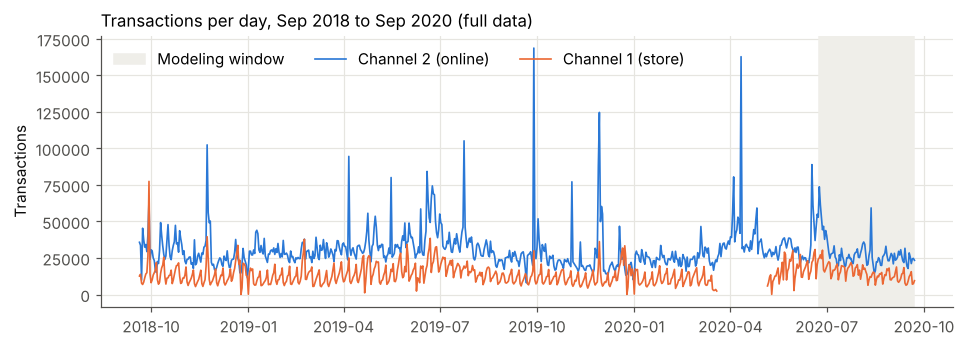

In [4]:
# 3. Daily transactions over two years
d = daily.pivot_table(index="t_dat", columns="sales_channel_id", values="n_tx", aggfunc="sum")
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axvspan(pd.Timestamp(cfg["sample"]["start_date"]), pd.Timestamp(cfg["sample"]["end_date"]), color="#efeee9", label="Modeling window")
ax.plot(d.index, d[2], lw=1.1, color=plots.BLUE, label="Channel 2 (online)")
ax.plot(d.index, d[1], lw=1.1, color=plots.ORANGE, label="Channel 1 (store)")
ax.set_title("Transactions per day, Sep 2018 to Sep 2020 (full data)")
ax.set_ylabel("Transactions")
ax.legend(loc="upper left", ncol=3)
plots.save(fig, "01_daily_transactions")

In [5]:
# 4. Modeling sample (last 13 weeks, ~20% of customers by a fixed hash rule)
ds = load_dataset(cfg)
tx = ds.transactions
pd.Series({"transactions": len(tx), "customers_in_sample": len(ds.customers), "share_of_all_customers": len(ds.customers) / FULL_COUNTS["customers"], "customers_who_bought": tx["cid"].nunique(), "articles_sold": tx["article_id"].nunique(), "first_day": tx["t_dat"].min().date(), "last_day": tx["t_dat"].max().date()})

transactions                  789049
customers_in_sample           278736
share_of_all_customers        0.2032
customers_who_bought          106650
articles_sold                  31178
first_day                 2020-06-24
last_day                  2020-09-22
dtype: object

In [6]:
# 5. Weekly split (week 0 = test, week 1 = validation, weeks 2-4 = training labels)
weeks = tx.groupby("week").agg(start=("t_dat", "min"), end=("t_dat", "max"), units=("article_id", "size"), customers=("cid", "nunique"), articles=("article_id", "nunique"))
weeks["role"] = ["test" if w == 0 else "valid" if w == 1 else "train labels" if w in cfg["weeks"]["train"] else "history only" for w in weeks.index]
weeks.assign(start=weeks["start"].dt.date, end=weeks["end"].dt.date)

,start,end,units,customers,articles,role
week,,,,,,
0,2020-09-16,2020-09-22,49001,14023,9798,test
1,2020-09-09,2020-09-15,52332,14753,10271,valid
2,2020-09-02,2020-09-08,53491,15368,10752,train labels
3,2020-08-26,2020-09-01,58197,16345,11058,train labels
4,2020-08-19,2020-08-25,52196,14641,11398,train labels
5,2020-08-12,2020-08-18,53273,14416,11219,history only
6,2020-08-05,2020-08-11,57887,15110,11277,history only
7,2020-07-29,2020-08-04,64152,16673,12333,history only
8,2020-07-22,2020-07-28,60892,16436,12558,history only


In [7]:
# 6. Types and missing values in the raw files
quality = pd.concat([quality_report(raw[n]).assign(table=n) for n in ["transactions", "customers", "articles"]], ignore_index=True)
quality.to_csv(cfg["paths"]["tables"] / "data_quality.csv", index=False)
quality

,column,dtype,missing,missing_pct,unique,table
0,t_dat,str,0,0.0000,91,transactions
1,customer_id,str,0,0.0000,106650,transactions
2,article_id,int64,0,0.0000,31178,transactions
3,price,float64,0,0.0000,4051,transactions
4,sales_channel_id,int64,0,0.0000,2,transactions
5,customer_id,str,0,0.0000,278736,customers
6,FN,float64,181680,65.1800,1,customers
7,Active,float64,184290,66.1200,1,customers
8,club_member_status,str,1218,0.4400,3,customers
9,fashion_news_frequency,str,3275,1.1700,4,customers


In [8]:
# 7. Duplicates
t = raw["transactions"]
lines = t.groupby(list(t.columns)).size()
pd.Series({"exact_duplicate_rows": int(t.duplicated().sum()), "share_of_rows": t.duplicated().mean(), "lines_with_more_than_1_unit": int((lines > 1).sum()), "max_units_on_one_line": int(lines.max()), "duplicate_customer_ids": int(raw["customers"]["customer_id"].duplicated().sum()), "duplicate_article_ids": int(raw["articles"]["article_id"].duplicated().sum())})

exact_duplicate_rows          66,416.0000
share_of_rows                      0.0842
lines_with_more_than_1_unit   57,332.0000
max_units_on_one_line             23.0000
duplicate_customer_ids             0.0000
duplicate_article_ids              0.0000
dtype: float64

In [9]:
# 8. Outliers (IQR rule)
price_out = iqr_outliers(tx["price"])
age = ds.customers["age"].dropna()
age_out = iqr_outliers(age)
pd.Series({"price_outliers": int(price_out.sum()), "price_outlier_share": price_out.mean(), "price_median": tx["price"].median(), "price_p99": tx["price"].quantile(0.99), "price_max": tx["price"].max(), "age_outliers": int(age_out.sum()), "age_outlier_min": age[age_out].min(), "age_max": age.max()})

price_outliers        30,951.0000
price_outlier_share        0.0392
price_median               0.0244
price_p99                  0.0847
price_max                  0.5068
age_outliers              42.0000
age_outlier_min           87.0000
age_max                   99.0000
dtype: float64

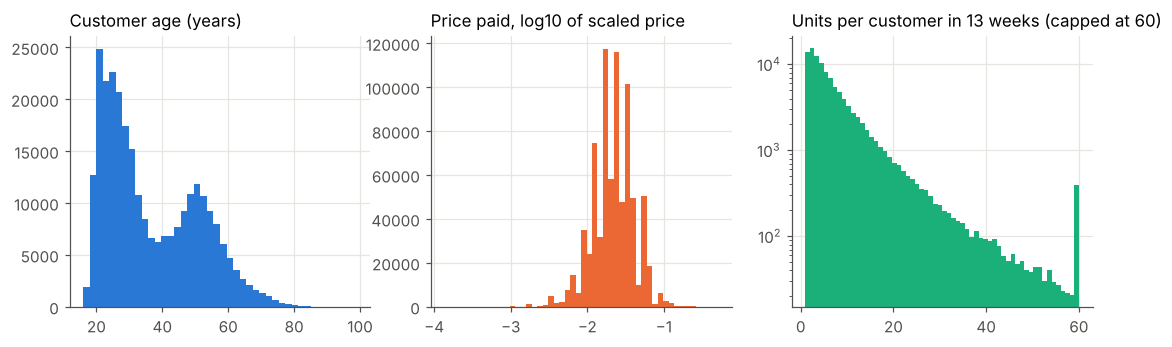

In [10]:
# 9. Distributions
per_cust = tx.groupby("cid").size()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].hist(ds.customers["age"].dropna(), bins=42, color=plots.BLUE)
axes[0].set_title("Customer age (years)")
axes[1].hist(np.log10(tx["price"]), bins=50, color=plots.ORANGE)
axes[1].set_title("Price paid, log10 of scaled price")
axes[2].hist(per_cust.clip(upper=60), bins=60, color=plots.AQUA)
axes[2].set_yscale("log")
axes[2].set_title("Units per customer in 13 weeks (capped at 60)")
plots.save(fig, "01_distributions")

np.float64(0.767409882022536)

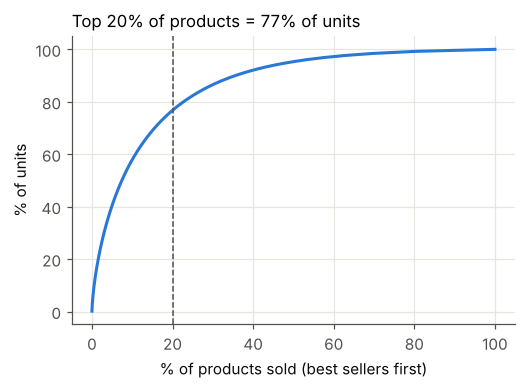

In [11]:
# 10. Long tail of product sales
counts = tx["article_id"].value_counts().to_numpy()
cum = np.cumsum(counts) / counts.sum()
share_top20 = cum[int(len(cum) * 0.2) - 1]
fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.plot(np.arange(1, len(cum) + 1) / len(cum) * 100, cum * 100, color=plots.BLUE, lw=2)
ax.axvline(20, color=plots.GRAY, lw=1, ls="--")
ax.set_xlabel("% of products sold (best sellers first)")
ax.set_ylabel("% of units")
ax.set_title(f"Top 20% of products = {share_top20 * 100:.0f}% of units")
plots.save(fig, "01_long_tail")
share_top20

In [12]:
# 11. Data dictionary
dd = as_frame()
dd.to_csv(cfg["paths"]["tables"] / "data_dictionary.csv", index=False)
(Path.cwd().parent / "docs" / "DATA_DICTIONARY.md").write_text(to_markdown(dd))
dd

,table,variable,type,unit,allowed_values_or_range,description
0,transactions,t_dat,date (string in raw file),day,2018-09-20 to 2020-09-22 (sample: 2020-06-24 t...,Purchase date. One row per unit sold
1,transactions,customer_id,string (64-char hex hash),,Matches customers.customer_id,Anonymized customer key
2,transactions,article_id,int64,,Matches articles.article_id,Product variant key (product + color)
3,transactions,price,float64,scaled currency,"0.00002 to 0.5915 (scaled by H&M, not real money)",Unit price paid
4,transactions,sales_channel_id,int64,,"1, 2 (2 is widely read as online, 1 as store)",Sales channel
5,customers,customer_id,string (64-char hex hash),,Unique per row,Anonymized customer key
6,customers,FN,float64 (flag),,1.0 or missing (missing = 0),Customer gets fashion news
7,customers,Active,float64 (flag),,1.0 or missing (missing = 0),Customer is active for communication
8,customers,club_member_status,string,,"ACTIVE, PRE-CREATE, LEFT CLUB, missing",Loyalty club status
9,customers,fashion_news_frequency,string,,"NONE, None, Regularly, Monthly, missing (None ...",Newsletter frequency
